# Industrial Surface Defect Detection System

## 1. Environment Setup and GPU Verification

In [ ]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

!nvidia-smi --query-gpu=name,memory.total,memory.free --format=csv

TensorFlow Version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
name, memory.total [MiB], memory.free [MiB]
Tesla T4, 15360 MiB, 14910 MiB


## 2. Dataset Upload and Initial Inspection

In [ ]:
import os
import zipfile

zip_path = "/content/archive.zip"

# Verify the ZIP file
file_exists = os.path.exists(zip_path)
print("File exists:", file_exists)

if not file_exists:
    raise FileNotFoundError(f"Dataset ZIP not found at: {zip_path}")

# Display archive size
file_size_mb = os.path.getsize(zip_path) / (1024 ** 2)
print(f"Archive size: {file_size_mb:.2f} MB")

# Inspect archive contents without extracting
with zipfile.ZipFile(zip_path, "r") as zip_file:
    file_paths = zip_file.namelist()

print("Total files inside archive:", len(file_paths))

print("\nFirst 30 file paths:")
for file_path in file_paths[:30]:
    print(file_path)

File exists: True
Archive size: 26.44 MB
Total files inside archive: 3600

First 30 file paths:
NEU-DET/train/annotations/crazing_1.xml
NEU-DET/train/annotations/crazing_10.xml
NEU-DET/train/annotations/crazing_100.xml
NEU-DET/train/annotations/crazing_101.xml
NEU-DET/train/annotations/crazing_102.xml
NEU-DET/train/annotations/crazing_103.xml
NEU-DET/train/annotations/crazing_104.xml
NEU-DET/train/annotations/crazing_105.xml
NEU-DET/train/annotations/crazing_106.xml
NEU-DET/train/annotations/crazing_107.xml
NEU-DET/train/annotations/crazing_108.xml
NEU-DET/train/annotations/crazing_109.xml
NEU-DET/train/annotations/crazing_11.xml
NEU-DET/train/annotations/crazing_110.xml
NEU-DET/train/annotations/crazing_111.xml
NEU-DET/train/annotations/crazing_112.xml
NEU-DET/train/annotations/crazing_113.xml
NEU-DET/train/annotations/crazing_114.xml
NEU-DET/train/annotations/crazing_115.xml
NEU-DET/train/annotations/crazing_116.xml
NEU-DET/train/annotations/crazing_117.xml
NEU-DET/train/annotations/

In [ ]:
import zipfile
from pathlib import Path

zip_path = "/content/archive.zip"
extract_path = Path("/content/neu_surface_defect")

with zipfile.ZipFile(zip_path, "r") as z:
    print("Archive integrity:", "Valid" if z.testzip() is None else "Corrupt")
    z.extractall(extract_path)

images = list(extract_path.rglob("*.jpg"))
xml_files = list(extract_path.rglob("*.xml"))

train_images = [p for p in images if "train" in p.parts]
validation_images = [p for p in images if "validation" in p.parts]

print("Dataset extracted to:", extract_path)
print("Main folders:", [p.name for p in extract_path.iterdir()])
print("Total images:", len(images))
print("Total XML files:", len(xml_files))
print("Training images:", len(train_images))
print("Validation images:", len(validation_images))

Archive integrity: Valid
Dataset extracted to: /content/neu_surface_defect
Main folders: ['NEU-DET']
Total images: 1800
Total XML files: 1800
Training images: 1440
Validation images: 360


## 3. Dataset Exploration and Class Distribution

In [ ]:
from collections import Counter

def get_label(path):
    return path.stem.rsplit("_", 1)[0]

train_counts = Counter(get_label(p) for p in train_images)
validation_counts = Counter(get_label(p) for p in validation_images)

print("Training class distribution:")
print(dict(sorted(train_counts.items())))

print("\nValidation class distribution:")
print(dict(sorted(validation_counts.items())))

Training class distribution:
{'crazing': 240, 'inclusion': 240, 'patches': 240, 'pitted_surface': 240, 'rolled-in_scale': 240, 'scratches': 240}

Validation class distribution:
{'crazing': 60, 'inclusion': 60, 'patches': 60, 'pitted_surface': 60, 'rolled-in_scale': 60, 'scratches': 60}


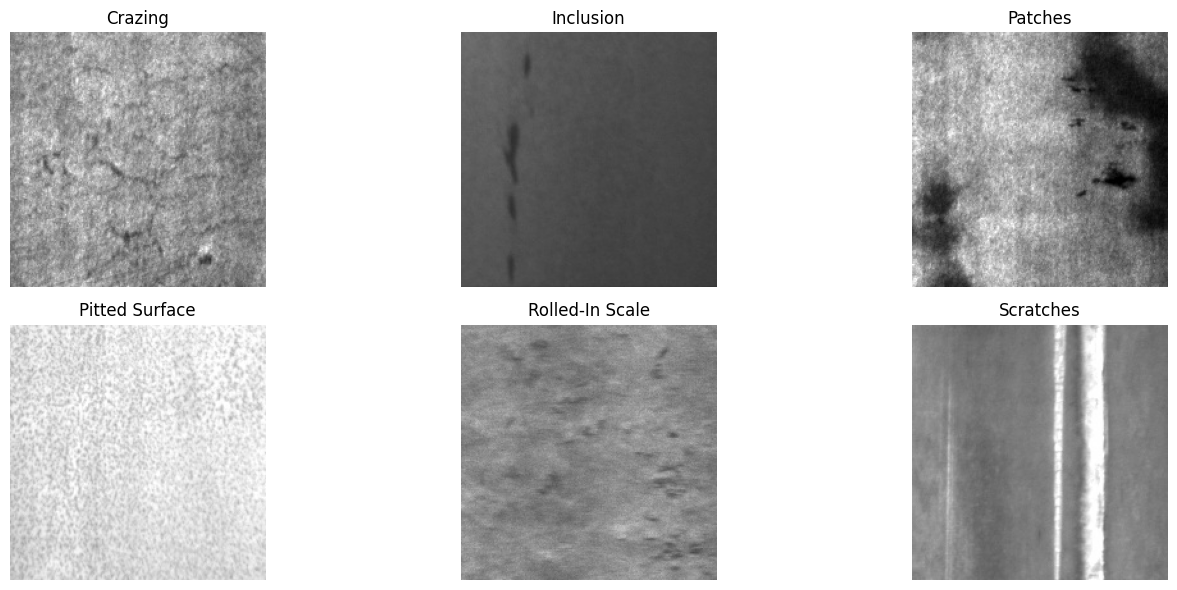

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

classes = sorted(train_counts.keys())

plt.figure(figsize=(15, 6))

for i, class_name in enumerate(classes):
    image_path = next(p for p in train_images if get_label(p) == class_name)

    plt.subplot(2, 3, i + 1)
    plt.imshow(Image.open(image_path), cmap="gray")
    plt.title(class_name.replace("_", " ").title())
    plt.axis("off")

plt.tight_layout()
plt.show()

## 4. Train, Validation, and Test Data Preparation

In [ ]:
from sklearn.model_selection import train_test_split
from collections import Counter

# Fixed class mappings
class_names = sorted(train_counts.keys())
class_to_index = {name: i for i, name in enumerate(class_names)}
index_to_class = {i: name for name, i in class_to_index.items()}

# Split existing validation images into validation and test sets
validation_labels = [get_label(p) for p in validation_images]

val_paths, test_paths, val_labels, test_labels = train_test_split(
    validation_images,
    validation_labels,
    test_size=0.5,
    random_state=42,
    stratify=validation_labels
)

train_paths = train_images
train_labels = [get_label(p) for p in train_paths]

print("Class mapping:", class_to_index)
print("\nTraining:", len(train_paths), dict(sorted(Counter(train_labels).items())))
print("Validation:", len(val_paths), dict(sorted(Counter(val_labels).items())))
print("Test:", len(test_paths), dict(sorted(Counter(test_labels).items())))

Class mapping: {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}

Training: 1440 {'crazing': 240, 'inclusion': 240, 'patches': 240, 'pitted_surface': 240, 'rolled-in_scale': 240, 'scratches': 240}
Validation: 180 {'crazing': 30, 'inclusion': 30, 'patches': 30, 'pitted_surface': 30, 'rolled-in_scale': 30, 'scratches': 30}
Test: 180 {'crazing': 30, 'inclusion': 30, 'patches': 30, 'pitted_surface': 30, 'rolled-in_scale': 30, 'scratches': 30}


In [ ]:
IMG_SIZE = (200, 200)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def create_dataset(paths, labels, training=False):
    paths = [str(p) for p in paths]
    labels = [class_to_index[label] for label in labels]

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        dataset = dataset.shuffle(
            len(paths), seed=42, reshuffle_each_iteration=True
        )

    return (
        dataset
        .map(load_image, num_parallel_calls=AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(AUTOTUNE)
    )

train_ds = create_dataset(train_paths, train_labels, training=True)
val_ds = create_dataset(val_paths, val_labels)
test_ds = create_dataset(test_paths, test_labels)

images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Pixel range:", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))
print("Sample labels:", labels[:10].numpy())

Image batch shape: (32, 200, 200, 3)
Label batch shape: (32,)
Pixel range: 0.0 to 1.0
Sample labels: [1 4 1 4 3 3 4 5 2 0]


## 5. Baseline Artificial Neural Network

In [ ]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

ann_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(200, 200, 3)),
    tf.keras.layers.Resizing(64, 64),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        use_bias=False,
        kernel_initializer="he_normal"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(6, activation="softmax")
], name="Baseline_ANN")

ann_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

ann_model.summary()

Model: "Baseline_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,572,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,574,150 (6.00 MB)

 Trainable params: 1,573,894 (6.00 MB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
ann_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        min_delta=0.001,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_delta=0.001,
        min_lr=1e-6
    )
]

ann_history = ann_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=ann_callbacks,
    verbose=1
)

Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.3229 - loss: 1.7182 - val_accuracy: 0.1889 - val_loss: 5.1127 - learning_rate: 1.0000e-04
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4146 - loss: 1.4835 - val_accuracy: 0.2500 - val_loss: 2.7374 - learning_rate: 1.0000e-04
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4729 - loss: 1.3495 - val_accuracy: 0.3611 - val_loss: 2.4111 - learning_rate: 1.0000e-04
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4771 - loss: 1.3199 - val_accuracy: 0.4333 - val_loss: 2.0353 - learning_rate: 1.0000e-04
Epoch 5/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5069 - loss: 1.2774 - val_accuracy: 0.3722 - val_loss: 2.0266 - learning_rate: 1.0000e-04
Epoch 6/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5250 - loss: 1.2311 - val_accuracy: 0.1833 - val_loss: 2.7254 - learning_rate: 1.0000e-04
Epoch 7/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5354 

## 6. Baseline ANN Performance Analysis

Restored ANN validation loss: 1.4333
Restored ANN validation accuracy: 38.33%
Best observed validation accuracy: 48.89%


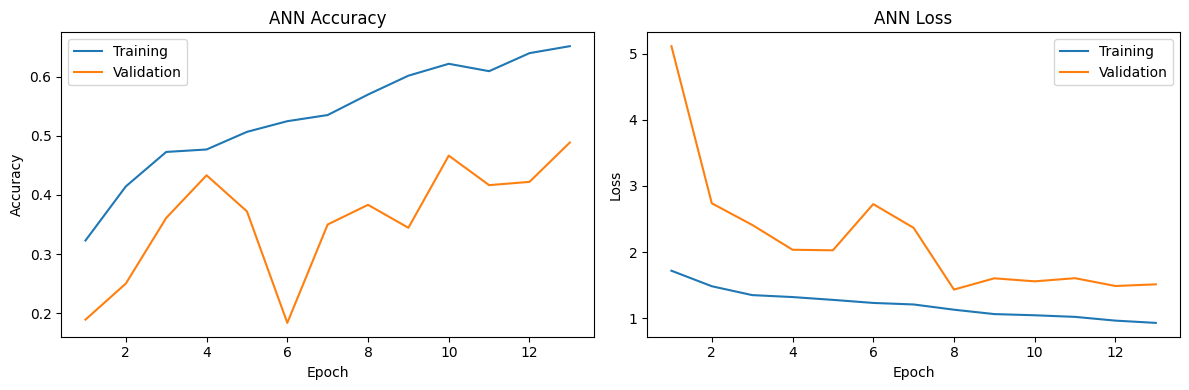

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

ann_val_loss, ann_val_accuracy = ann_model.evaluate(val_ds, verbose=0)

print(f"Restored ANN validation loss: {ann_val_loss:.4f}")
print(f"Restored ANN validation accuracy: {ann_val_accuracy:.2%}")
print(f"Best observed validation accuracy: {max(ann_history.history['val_accuracy']):.2%}")

epochs = range(1, len(ann_history.history["loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, ann_history.history["accuracy"], label="Training")
plt.plot(epochs, ann_history.history["val_accuracy"], label="Validation")
plt.title("ANN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, ann_history.history["loss"], label="Training")
plt.plot(epochs, ann_history.history["val_loss"], label="Validation")
plt.title("ANN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## 7. Custom CNN with Data Augmentation

In [ ]:
from tensorflow.keras import regularizers

tf.keras.utils.set_random_seed(42)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomContrast(0.10)
])

cnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(200, 200, 3)),
    data_augmentation,

    tf.keras.layers.Conv2D(32, 3, padding="same",
                           activation="relu",
                           kernel_regularizer=regularizers.l2(1e-4)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, padding="same",
                           activation="relu",
                           kernel_regularizer=regularizers.l2(1e-4)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, padding="same",
                           activation="relu",
                           kernel_regularizer=regularizers.l2(1e-4)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.35),
    tf.keras.layers.Dense(6, activation="softmax")
], name="Custom_CNN")

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,894 (398.02 KB)

 Trainable params: 101,894 (398.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/content/best_custom_cnn.keras",
        monitor="val_loss",
        save_best_only=True
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        min_delta=0.001,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_delta=0.001,
        min_lr=1e-6
    )
]

cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=cnn_callbacks,
    verbose=1
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.1764 - loss: 1.7920 - val_accuracy: 0.1667 - val_loss: 1.7752 - learning_rate: 3.0000e-04
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.1896 - loss: 1.7812 - val_accuracy: 0.3167 - val_loss: 1.7623 - learning_rate: 3.0000e-04
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.2424 - loss: 1.7444 - val_accuracy: 0.3778 - val_loss: 1.6758 - learning_rate: 3.0000e-04
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.3569 - loss: 1.6055 - val_accuracy: 0.4333 - val_loss: 1.4182 - learning_rate: 3.0000e-04
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.4812 - loss: 1.3153 - val_accuracy: 0.5222 - val_loss: 1.1985 - learning_rate: 3.0000e-04
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.5368 - loss: 1.1005 - val_accuracy: 0.4778 - val_loss: 1.2508 - learning_rate: 3.0000e-04
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.5917

## 8. Custom CNN Performance Analysis

Restored CNN validation loss: 1.0662
Restored CNN validation accuracy: 50.00%
Best observed validation accuracy: 54.44%


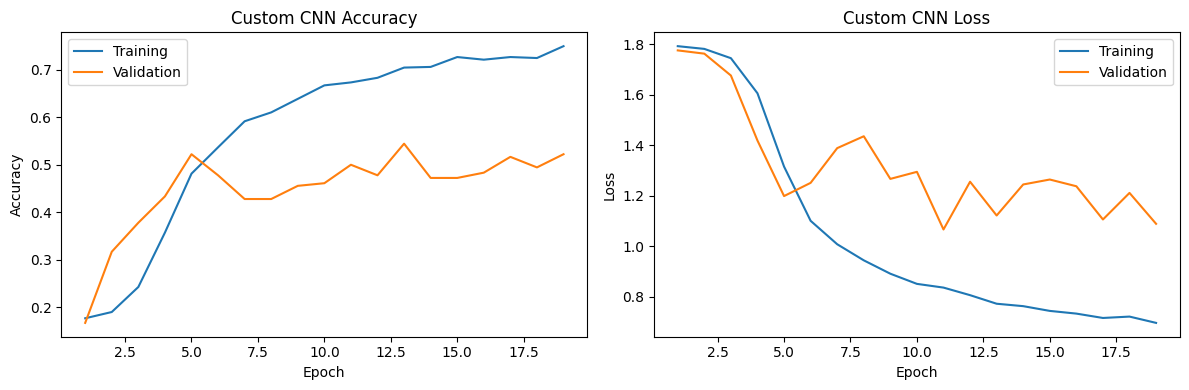

In [ ]:
cnn_val_loss, cnn_val_accuracy = cnn_model.evaluate(val_ds, verbose=0)

print(f"Restored CNN validation loss: {cnn_val_loss:.4f}")
print(f"Restored CNN validation accuracy: {cnn_val_accuracy:.2%}")
print(f"Best observed validation accuracy: {max(cnn_history.history['val_accuracy']):.2%}")

epochs = range(1, len(cnn_history.history["loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, cnn_history.history["accuracy"], label="Training")
plt.plot(epochs, cnn_history.history["val_accuracy"], label="Validation")
plt.title("Custom CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, cnn_history.history["loss"], label="Training")
plt.plot(epochs, cnn_history.history["val_loss"], label="Validation")
plt.title("Custom CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## 9. Transfer Learning with MobileNetV2

In [ ]:
tf.keras.utils.set_random_seed(42)

transfer_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomContrast(0.10)
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(200, 200, 3))
x = tf.keras.layers.Resizing(224, 224)(inputs)
x = transfer_augmentation(x)
x = tf.keras.layers.Rescaling(scale=2.0, offset=-1.0)(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.30)(x)
outputs = tf.keras.layers.Dense(6, activation="softmax")(x)

transfer_model = tf.keras.Model(
    inputs, outputs, name="MobileNetV2_Transfer_Learning"
)

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

Model: "MobileNetV2_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_1 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
transfer_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/content/best_transfer_frozen.keras",
        monitor="val_loss",
        save_best_only=True
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        min_delta=0.001,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_delta=0.001,
        min_lr=1e-6
    )
]

transfer_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=transfer_callbacks,
    verbose=1
)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 131ms/step - accuracy: 0.7486 - loss: 0.7755 - val_accuracy: 0.9722 - val_loss: 0.2438 - learning_rate: 0.0010
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.9757 - loss: 0.1441 - val_accuracy: 0.9778 - val_loss: 0.1392 - learning_rate: 0.0010
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.9861 - loss: 0.0869 - val_accuracy: 1.0000 - val_loss: 0.0993 - learning_rate: 0.0010
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.9889 - loss: 0.0696 - val_accuracy: 0.9889 - val_loss: 0.0887 - learning_rate: 0.0010
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.9903 - loss: 0.0494 - val_accuracy: 1.0000 - val_loss: 0.0703 - learning_rate: 0.0010
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.9896 - loss: 0.0466 - val_accuracy: 1.0000 - val_loss: 0.0655 - learning_rate: 0.0010
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.9944 - loss: 0.0334 - val_a

## 10. Data Leakage Check and Final Test Evaluation

In [ ]:
import hashlib
from PIL import Image

def image_hash(path):
    image = Image.open(path).convert("L")
    return hashlib.sha256(image.tobytes()).hexdigest()

train_hashes = {image_hash(p) for p in train_paths}
val_hashes = {image_hash(p) for p in val_paths}
test_hashes = {image_hash(p) for p in test_paths}

print("Train–Validation duplicates:", len(train_hashes & val_hashes))
print("Train–Test duplicates:", len(train_hashes & test_hashes))
print("Validation–Test duplicates:", len(val_hashes & test_hashes))

assert not (train_hashes & val_hashes)
assert not (train_hashes & test_hashes)
assert not (val_hashes & test_hashes)

best_transfer_model = tf.keras.models.load_model(
    "/content/best_transfer_frozen.keras"
)

test_loss, test_accuracy = best_transfer_model.evaluate(
    test_ds, verbose=0
)

print(f"\nFinal test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_accuracy:.2%}")

Train–Validation duplicates: 0
Train–Test duplicates: 0
Validation–Test duplicates: 0

Final test loss: 0.0087
Final test accuracy: 100.00%


                 precision    recall  f1-score   support

        Crazing     1.0000    1.0000    1.0000        30
      Inclusion     1.0000    1.0000    1.0000        30
        Patches     1.0000    1.0000    1.0000        30
 Pitted Surface     1.0000    1.0000    1.0000        30
Rolled-In Scale     1.0000    1.0000    1.0000        30
      Scratches     1.0000    1.0000    1.0000        30

       accuracy                         1.0000       180
      macro avg     1.0000    1.0000    1.0000       180
   weighted avg     1.0000    1.0000    1.0000       180



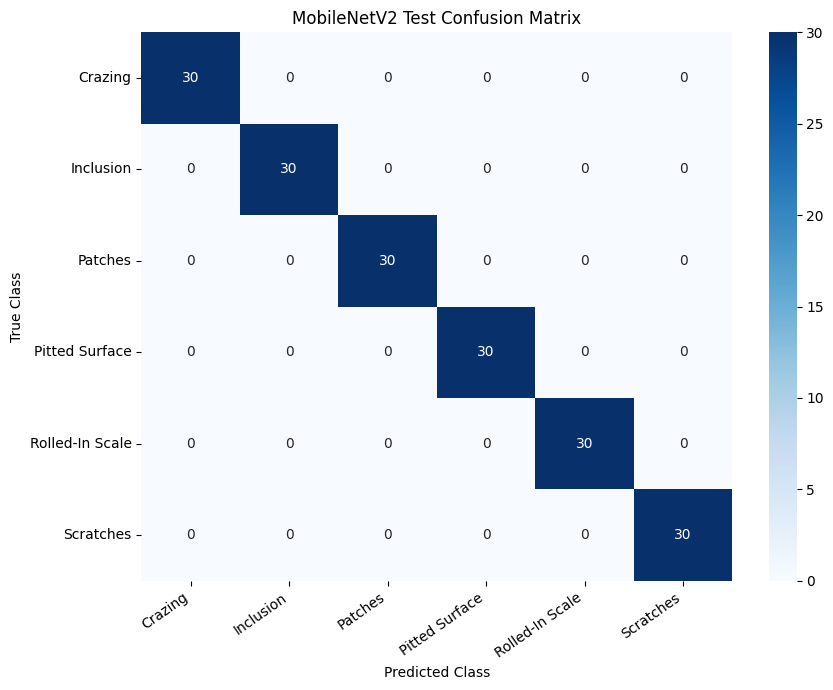

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

test_probabilities = best_transfer_model.predict(test_ds, verbose=0)
test_predictions = np.argmax(test_probabilities, axis=1)
test_true = np.concatenate([labels.numpy() for _, labels in test_ds])

print(classification_report(
    test_true,
    test_predictions,
    target_names=[name.replace("_", " ").title() for name in class_names],
    digits=4
))

cm = confusion_matrix(test_true, test_predictions)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[name.replace("_", " ").title() for name in class_names],
    yticklabels=[name.replace("_", " ").title() for name in class_names]
)
plt.title("MobileNetV2 Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 11. Final Model Comparison

,Model,Test Accuracy,Test Loss
0,Baseline ANN,0.4222,1.3645
1,Custom CNN,0.5167,1.0803
2,MobileNetV2,1.0000,0.0087


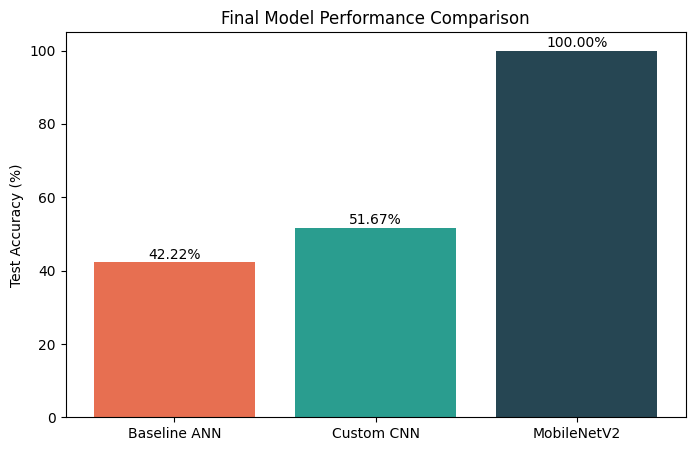

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

best_custom_cnn = tf.keras.models.load_model(
    "/content/best_custom_cnn.keras"
)

ann_test_loss, ann_test_acc = ann_model.evaluate(test_ds, verbose=0)
cnn_test_loss, cnn_test_acc = best_custom_cnn.evaluate(test_ds, verbose=0)

results = pd.DataFrame({
    "Model": ["Baseline ANN", "Custom CNN", "MobileNetV2"],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        test_accuracy
    ],
    "Test Loss": [
        ann_test_loss,
        cnn_test_loss,
        test_loss
    ]
})

display(results.round(4))

plt.figure(figsize=(8, 5))
bars = plt.bar(
    results["Model"],
    results["Test Accuracy"] * 100,
    color=["#e76f51", "#2a9d8f", "#264653"]
)

plt.ylabel("Test Accuracy (%)")
plt.title("Final Model Performance Comparison")
plt.ylim(0, 105)

for bar, accuracy in zip(bars, results["Test Accuracy"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{accuracy:.2%}",
        ha="center"
    )

plt.show()

## 12. Prediction Confidence Analysis

Minimum confidence: 87.82%
Mean confidence: 99.15%
Median confidence: 99.90%
Predictions below 90% confidence: 2


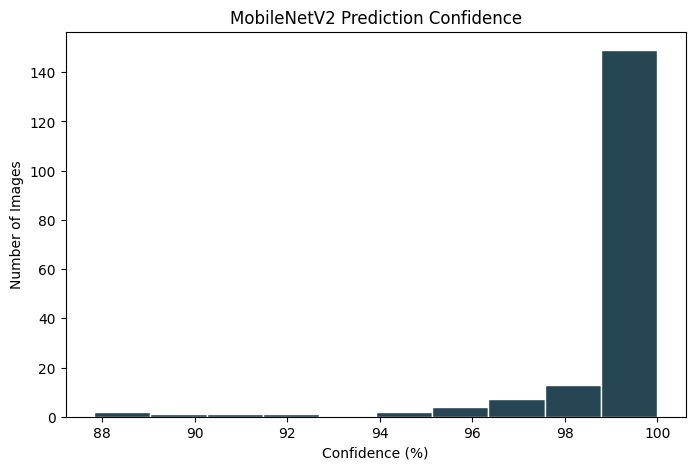

In [ ]:
test_confidence = np.max(test_probabilities, axis=1)

print(f"Minimum confidence: {test_confidence.min():.2%}")
print(f"Mean confidence: {test_confidence.mean():.2%}")
print(f"Median confidence: {np.median(test_confidence):.2%}")
print(f"Predictions below 90% confidence: {(test_confidence < 0.90).sum()}")

plt.figure(figsize=(8, 5))
plt.hist(test_confidence * 100, bins=10, color="#264653", edgecolor="white")
plt.title("MobileNetV2 Prediction Confidence")
plt.xlabel("Confidence (%)")
plt.ylabel("Number of Images")
plt.show()

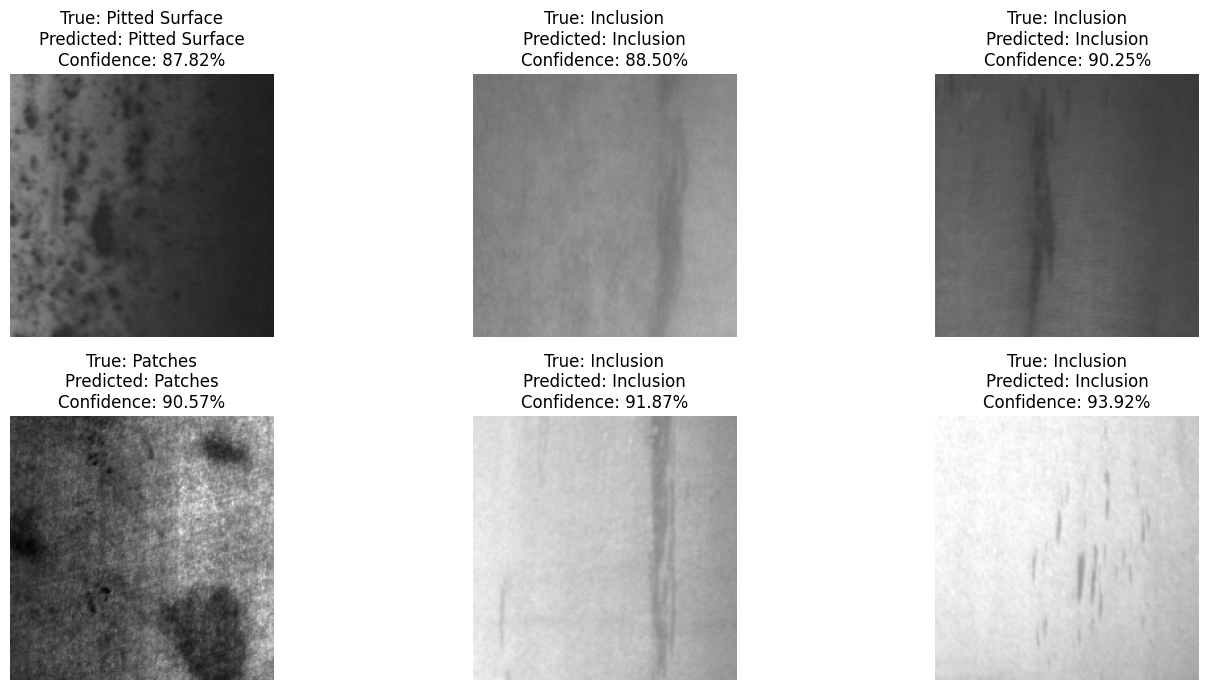

In [ ]:
lowest_indices = np.argsort(test_confidence)[:6]

plt.figure(figsize=(15, 7))

for i, index in enumerate(lowest_indices):
    true_name = index_to_class[int(test_true[index])]
    predicted_name = index_to_class[int(test_predictions[index])]

    plt.subplot(2, 3, i + 1)
    plt.imshow(Image.open(test_paths[index]), cmap="gray")
    plt.title(
        f"True: {true_name.replace('_', ' ').title()}\n"
        f"Predicted: {predicted_name.replace('_', ' ').title()}\n"
        f"Confidence: {test_confidence[index]:.2%}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

## 13. Grad-CAM Model Explainability

In [ ]:
# Access the trained MobileNetV2 and its final feature layer
mobilenet_base = best_transfer_model.get_layer("mobilenetv2_1.00_224")

feature_extractor = tf.keras.Model(
    mobilenet_base.input,
    mobilenet_base.get_layer("out_relu").output
)

def generate_gradcam(image_batch):
    resized = best_transfer_model.get_layer("resizing_1")(image_batch)
    augmented = best_transfer_model.get_layer("sequential_2")(
        resized, training=False
    )
    scaled = best_transfer_model.get_layer("rescaling_1")(augmented)

    with tf.GradientTape() as tape:
        feature_maps = feature_extractor(scaled)
        pooled = best_transfer_model.get_layer(
            "global_average_pooling2d_2"
        )(feature_maps)
        dropped = best_transfer_model.get_layer(
            "dropout_3"
        )(pooled, training=False)
        predictions = best_transfer_model.get_layer("dense_5")(dropped)

        predicted_class = tf.argmax(predictions[0])
        class_score = predictions[:, predicted_class]

    gradients = tape.gradient(class_score, feature_maps)
    weights = tf.reduce_mean(gradients, axis=(0, 1, 2))
    heatmap = tf.reduce_sum(feature_maps[0] * weights, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy(), int(predicted_class)

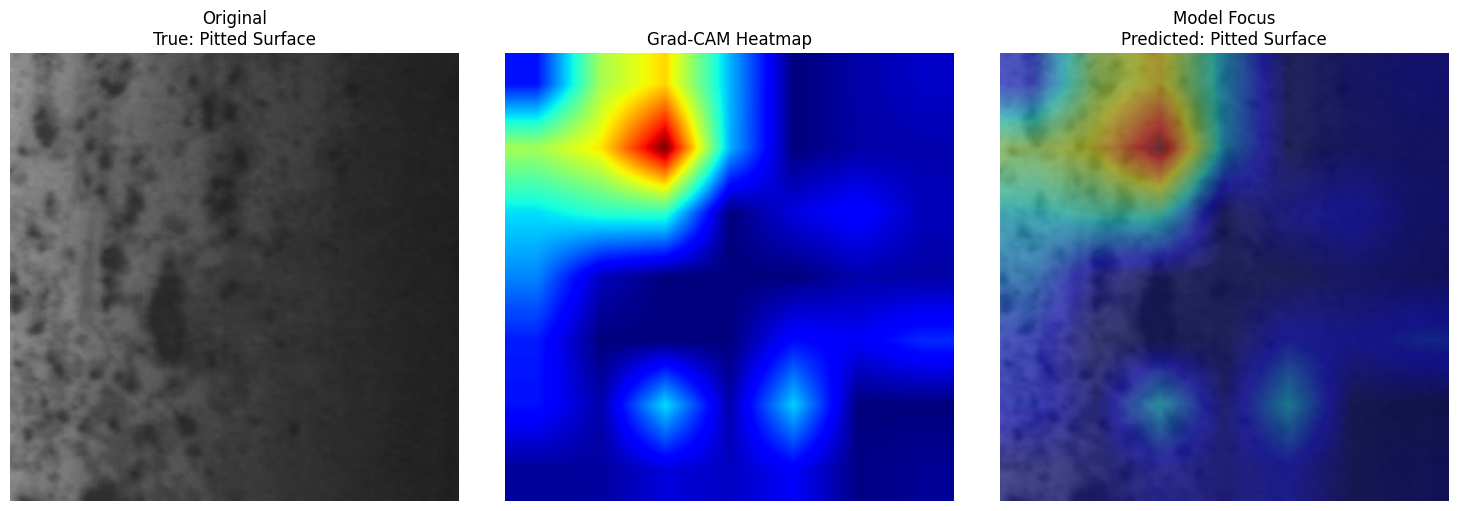

In [ ]:
hardest_index = int(np.argmin(test_confidence))
image_path = test_paths[hardest_index]

image = tf.keras.utils.load_img(
    image_path,
    target_size=(200, 200),
    color_mode="rgb"
)
image_array = tf.keras.utils.img_to_array(image) / 255.0
image_batch = np.expand_dims(image_array, axis=0)

heatmap, predicted_index = generate_gradcam(image_batch)
heatmap_resized = tf.image.resize(
    heatmap[..., np.newaxis], (200, 200)
).numpy().squeeze()

true_name = index_to_class[int(test_true[hardest_index])]
predicted_name = index_to_class[predicted_index]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_array)
plt.title(f"Original\nTrue: {true_name.replace('_', ' ').title()}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image_array)
plt.imshow(heatmap_resized, cmap="jet", alpha=0.45)
plt.title(
    f"Model Focus\nPredicted: {predicted_name.replace('_', ' ').title()}"
)
plt.axis("off")

plt.tight_layout()
plt.show()

## 14. Production Inference Pipeline

In [ ]:
def predict_defect(image_path, model=best_transfer_model):
    image = tf.keras.utils.load_img(
        image_path,
        target_size=(200, 200),
        color_mode="rgb"
    )

    image_array = tf.keras.utils.img_to_array(image) / 255.0
    image_batch = np.expand_dims(image_array, axis=0)

    probabilities = model.predict(image_batch, verbose=0)[0]
    top_indices = np.argsort(probabilities)[::-1][:3]

    return {
        "predicted_class": index_to_class[int(top_indices[0])],
        "confidence": float(probabilities[top_indices[0]]),
        "top_3": [
            (index_to_class[int(i)], float(probabilities[i]))
            for i in top_indices
        ]
    }

prediction = predict_defect(test_paths[0])

print("Predicted class:", prediction["predicted_class"])
print(f"Confidence: {prediction['confidence']:.2%}")
print("Top 3 predictions:")

for class_name, probability in prediction["top_3"]:
    print(f"  {class_name}: {probability:.2%}")

Predicted class: patches
Confidence: 98.24%
Top 3 predictions:
  patches: 98.24%
  inclusion: 0.64%
  rolled-in_scale: 0.47%


## 15. Final Model Export

In [ ]:
import json
import shutil
from pathlib import Path

export_dir = Path("/content/surface_defect_export")
export_dir.mkdir(exist_ok=True)

model_path = export_dir / "surface_defect_model.keras"
metadata_path = export_dir / "model_metadata.json"

best_transfer_model.save(model_path)

metadata = {
    "model_name": "MobileNetV2 Surface Defect Classifier",
    "class_names": class_names,
    "class_to_index": class_to_index,
    "input_size": [200, 200, 3],
    "input_pixel_range": [0.0, 1.0],
    "test_accuracy": float(test_accuracy),
    "test_loss": float(test_loss)
}

with open(metadata_path, "w") as file:
    json.dump(metadata, file, indent=4)

zip_path = shutil.make_archive(
    "/content/surface_defect_final",
    "zip",
    export_dir
)

print("Model saved:", model_path)
print("Metadata saved:", metadata_path)
print("Export ZIP:", zip_path)
print(f"ZIP size: {Path(zip_path).stat().st_size / (1024**2):.2f} MB")

Model saved: /content/surface_defect_export/surface_defect_model.keras
Metadata saved: /content/surface_defect_export/model_metadata.json
Export ZIP: /content/surface_defect_final.zip
ZIP size: 8.13 MB


In [ ]:
from google.colab import files
files.download("/content/surface_defect_final.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>